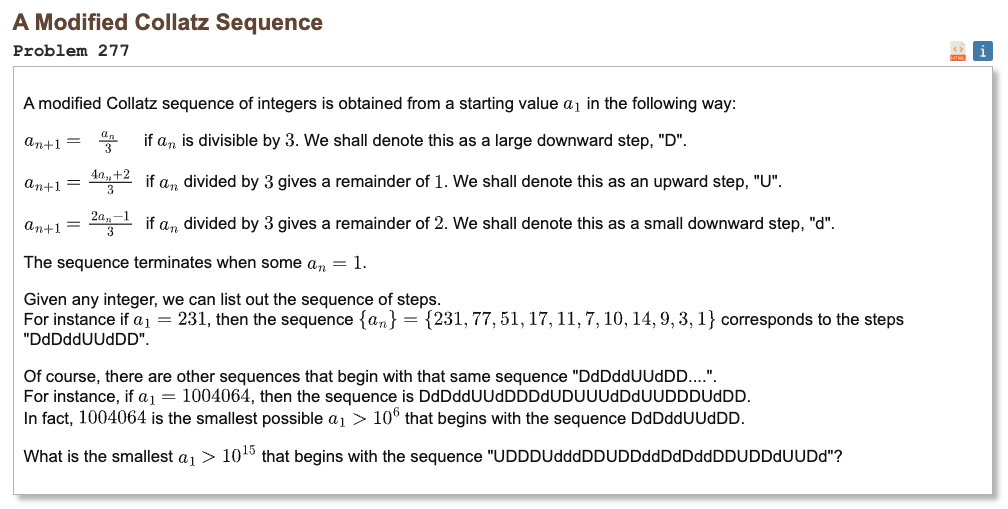

## Initial approach

* one important detail in the problem statement is easy to miss: we are not looking for the smallest starting value overall, we need the smallest one that is bigger than 10^15
* instead of trying huge starting numbers one by one, it is much better to start from the given step pattern and work backward
* each letter tells us how to recover the previous value from the current one, so we can undo the whole sequence step by step
* after undoing all the steps, the starting number can be written as a simple linear expression based on one unknown final value
* then the only thing left is to choose that unknown value so the expression becomes an integer
* that gives a repeating pattern of valid choices, not just one single value
* because of that, the possible starting values also form a regular sequence with a fixed gap
* so once we know the first valid one and the gap, we can jump straight to the first starting value above 10^15

In [1]:
%%time
from math import gcd

pattern = "UDDDUdddDDUDDddDdDddDDUDDdUUDd"
limit = 10**15

A, B, C = 1, 0, 1

for ch in reversed(pattern):
    if ch == "D":
        A, B = 3 * A, 3 * B
    elif ch == "d":
        A, B, C = 3 * A, 3 * B + C, 2 * C
    else:
        A, B, C = 3 * A, 3 * B - 2 * C, 4 * C

    g = gcd(gcd(A, B), C)
    A //= g
    B //= g
    C //= g

t0 = (-B * pow(A, -1, C)) % C
start0 = (A * t0 + B) // C

k = (limit + 1 - start0 + A - 1) // A
result = start0 + k * A

print("Result:", result)

Result: 1125977393124310
CPU times: user 141 μs, sys: 47 μs, total: 188 μs
Wall time: 155 μs
